# ResNet CIFAR-10 실습

- 가상환경 생성: `conda create -n resnet_cifar10 python=3.10 -y`

- 주피터 커널을 resnet_cifar10으로 변경.

- 터미널을 사용하면 `conda activate resnet_cifar10` 사용.

### 환경 설정 과정

In [10]:
!python3 -c "import sys; print('Python version:', sys.version)"

Python version: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]


In [11]:
# !conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia -y


In [12]:
# !conda install -n resnet_cifar10 mkl mkl-include -y

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [13]:
!conda list

# packages in environment at /home/theo_lab/miniconda3/envs/resnet_cifar10:
#
# Name                      Version          Build                  Channel
_libgcc_mutex               0.1              main
_openmp_mutex               4.5              7_kmp_llvm             conda-forge
asttokens                   3.0.1            pyhd8ed1ab_0           conda-forge
binutils_impl_linux-64      2.40             h5293946_0
binutils_linux-64           2.40.0           hc2dff05_2
bzip2                       1.0.8            h5eee18b_6
ca-certificates             2026.2.25        hbd8a1cb_0             conda-forge
certifi                     2026.2.25        pyhd8ed1ab_0           conda-forge
comm                        0.2.3            pyhe01879c_0           conda-forge
contourpy                   1.3.2            pypi_0                 pypi
cycler                      0.12.1           pypi_0                 pypi
debugpy                     1.8.20           py310h25320af_0        conda-forge
de

In [14]:
# !conda install mkl==2024.0.0 -c conda-forge -y

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [15]:
# !conda uninstall pytorch torchvision torchaudio pytorch-cuda -y

# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

2 channel Terms of Service accepted

PackagesNotFoundError: The following packages are missing from the target environment:

  - torchvision
  - torchaudio
  - pytorch-cuda
  - pytorch


Looking in indexes: https://download.pytorch.org/whl/cu121


In [16]:
!ls

00_deep_learning_from_scratch.md
01_torch_basic.ipynb
03_Linear_regression.ipynb
04_binary_classification.ipynb
05_1_multiclass_classification.ipynb
05_2_multiclass_classification_short.ipynb
05_3_multiclass_classification_CIFAR10.ipynb
06_batchnorm_dropout.ipynb
07_CNN.ipynb
08_multiclass_classification_CIFAR10_aug.ipynb
09_VGGnet_test.ipynb
10_mininet_test.ipynb
11_Custom_Dataset.ipynb
12_multiclass_classification_STL10.ipynb
etc
images
resnet_study.md
toy_resnet_cifar10.ipynb


In [17]:
!cd ..
!ls

00_deep_learning_from_scratch.md
01_torch_basic.ipynb
03_Linear_regression.ipynb
04_binary_classification.ipynb
05_1_multiclass_classification.ipynb
05_2_multiclass_classification_short.ipynb
05_3_multiclass_classification_CIFAR10.ipynb
06_batchnorm_dropout.ipynb
07_CNN.ipynb
08_multiclass_classification_CIFAR10_aug.ipynb
09_VGGnet_test.ipynb
10_mininet_test.ipynb
11_Custom_Dataset.ipynb
12_multiclass_classification_STL10.ipynb
etc
images
resnet_study.md
toy_resnet_cifar10.ipynb


In [18]:
# !pip uninstall torch torchvision torchaudio -y
# !conda uninstall pytorch torchvision torchaudio pytorch-cuda -y

# !rm -rf ~/miniconda3/envs/resnet_cifar10/lib/python3.10/site-packages/torch*

# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
2 channel Terms of Service accepted

PackagesNotFoundError: The following packages are missing from the target environment:

  - torchaudio
  - pytorch
  - torchvision
  - pytorch-cuda


Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp310-cp310-linux_x86_64.whl (780.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp310-cp310-linux_x86_64.whl (7.3 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp310-cp310-linux_x86_64.whl (3.4 

In [19]:
# !pip install matplotlib

### Import 및 세팅

In [20]:
import torch
print(torch.cuda.is_available())

True


In [23]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


In [22]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


### Hyper Parameters & Settings

In [ ]:
batch_size = 128
LR = 0.1 # 32k과 48k에서 낮춰줘야함

### Data

In [ ]:
transform = transforms.ToTensor()

train_DS = datasets.CIFAR10(root='~/resnet_cifar10/data', train = True, download = True, transform = transform)
test_DS = datasets.CIFAR10(root='~/resnet_cifar10/data', train = False, download = True, transform = transform)

100.0%


Extracting /home/theo_lab/resnet_cifar10/data/cifar-10-python.tar.gz to /home/theo_lab/resnet_cifar10/data
Files already downloaded and verified


In [27]:
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=batch_size, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=batch_size, shuffle=False)

In [31]:
print(train_DS.class_to_idx)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


torch.Size([128, 3, 32, 32])
라벨 이름: bird


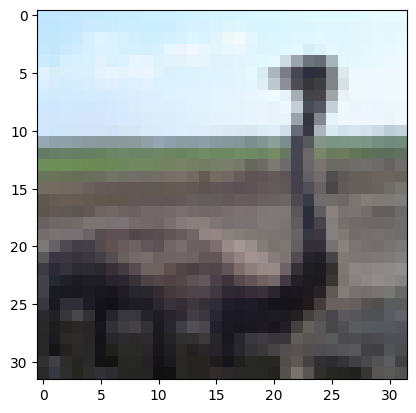

In [42]:
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape)

plt.imshow(x_batch[0].permute(1,2,0))
print("라벨 이름:", test_DS.classes[y_batch[0]])

In [52]:
# ResNet은 기본적으로 아래와 같은 Residual Block 매우 많이 쌓기(아마 논문에 있는 56개 레이어를 쌓을 듯) 때문에 일단 클래스로 만들고 나중에 계속 활용.
class Residual_Block(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1, padding=1): # 디폴트 값은 이렇게
        super().__init__()

        self.stride = stride
        self.padding = padding
        self.input_channels = input_channels
        self.output_channels = output_channels

        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=stride, padding=padding, bias=False) # 커널 사이즈는 항상 3개 쓸 듯?
        self.bn1 = nn.BatchNorm2d(output_channels) # 논문에서 쓰라고 함
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        identity = x

        # 잔차 함수 통과 (F(x))
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # 만약 인풋과 아웃풋이 다르면 원래는 정사영시키는게 맞지만, 그냥 stride 2로 사이즈 줄이고 패딩으로 채워서 맞춰버리기
        if self.stride != 1 or self.input_channels != self.output_channels:
            identity = identity[:, :, ::2, ::2]
            pad_channels = self.output_channels - self.input_channels
            identity = F.pad(identity, (0,0,0,0,0, pad_channels))

        out += identity # F(x) + x

        out = self.relu2(out) # 마지막으로 relu 통과

        return out


In [53]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # 시작 부분
        self.conv1 = nn.Conv2d(3,16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()

        blocks1 = []
        for _ in range(9):
            blocks1.append(Residual_Block(16,16, stride=1, padding=1))
        self.layer1 = nn.Sequential(*blocks1)
        
        blocks2 = []
        blocks2.append(Residual_Block(16,32, stride=2))
        for _ in range(8):
            blocks2.append(Residual_Block(32,32, stride=2))
        self.layer2 = nn.Sequential(*blocks2)

        blocks3 = []
        blocks3.append(Residual_Block(32,64, stride=2))
        for _ in range(8):
            blocks3.append(Residual_Block(64,64, stride=1))
        self.layer3 = nn.Sequential(*blocks3)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(64,10)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x


In [54]:
model = ResNet().to(DEVICE)

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay= 0.0001) # 논문에서 쓰라고 함

# max_iterations = 64000 # 논문에서 그렇게함
max_iterations = 32000

In [56]:
total_iterations = 0
epoch = 0


while total_iterations < max_iterations:
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_DL:
        
        if total_iterations == 32000:
            print("========LR을 0.01로 감소시킵니다========")
            for param_group in optimizer.param_groups:
                param_group['lr'] = 0.01 # lr 수정
        elif total_iterations == 48000:
            print("========LR을 0.001로 감소시킵니다=======")
            for param_group in optimizer.param_groups:
                param_group['lr'] = 0.001
    
        if total_iterations >= max_iterations:
            break

        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)

        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        total_iterations += 1

        if total_iterations % 100 == 0:
            print(f"epoch: {epoch}, iteration: {total_iterations}/{max_iterations}, loss: {loss.item():.4f}")

    epoch += 1

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for test_inputs, test_targets in test_DL:
            test_inputs, test_targets = test_inputs.to(DEVICE), test_targets.to(DEVICE)

            test_outputs = model(test_inputs)
            loss = criterion(test_outputs, test_targets)
            
            test_loss += loss.item()
            _, test_predicted = test_outputs.max(1)
            test_total += test_targets.size(0)
            test_correct += test_predicted.eq(test_targets).sum().item()
    test_acc = 100. * test_correct / test_total
    train_acc = 100. * correct / total
    print(f"에포크 {epoch} 끝, train acc: {train_acc:.2f}, test acc: {test_acc:.2f}")

print("학습 끝!")

epoch: 0, iteration: 100/32000, loss: 2.2820
epoch: 0, iteration: 200/32000, loss: 2.1833
epoch: 0, iteration: 300/32000, loss: 1.7369
에포크 1 끝, train acc: 22.93, test acc: 32.51
epoch: 1, iteration: 400/32000, loss: 1.6992
epoch: 1, iteration: 500/32000, loss: 1.8169
epoch: 1, iteration: 600/32000, loss: 1.6274
epoch: 1, iteration: 700/32000, loss: 1.6582
에포크 2 끝, train acc: 38.10, test acc: 43.64
epoch: 2, iteration: 800/32000, loss: 1.5389
epoch: 2, iteration: 900/32000, loss: 1.4761
epoch: 2, iteration: 1000/32000, loss: 1.4251
epoch: 2, iteration: 1100/32000, loss: 1.3238
에포크 3 끝, train acc: 46.40, test acc: 42.11
epoch: 3, iteration: 1200/32000, loss: 1.4895
epoch: 3, iteration: 1300/32000, loss: 1.4142
epoch: 3, iteration: 1400/32000, loss: 1.3171
epoch: 3, iteration: 1500/32000, loss: 1.4196
에포크 4 끝, train acc: 51.96, test acc: 52.66
epoch: 4, iteration: 1600/32000, loss: 1.3746
epoch: 4, iteration: 1700/32000, loss: 1.0717
epoch: 4, iteration: 1800/32000, loss: 1.1567
epoch: 4,

In [ ]:
import os
save_path = os.path.expanduser("~/resnet_cifar10/resnet56_cifar10_weights.pth")
torch.save(model.state_dict(), save_path)




실제 정답: deer
모델 예측: frog


/tmp/ipykernel_2048089/2571645054.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(save_path))


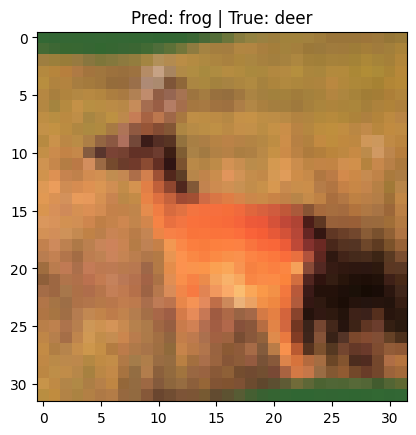

In [98]:
import torch
import random
import matplotlib.pyplot as plt

loaded_model = ResNet().to(DEVICE)
loaded_model.load_state_dict(torch.load(save_path))
loaded_model.eval()

random_idx = random.randint(0, len(test_DS) - 1)

single_image, true_label = test_DS[random_idx]

single_image_gpu = single_image.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output = loaded_model(single_image_gpu)
    _, predicted = output.max(1)
    pred_label = predicted.item()

print(f"실제 정답: {test_DS.classes[true_label]}")
print(f"모델 예측: {test_DS.classes[pred_label]}")

img_for_plot = single_image.permute(1, 2, 0).cpu().numpy()
plt.imshow(img_for_plot)
plt.title(f"Pred: {test_DS.classes[pred_label]} | True: {test_DS.classes[true_label]}")
plt.show()

- 근데 이 분들은 수동으로 이걸 조절하셨는데.. 그냥 ADAM을 쓰면 되는거 아님??